# Lab 6: Simple linear regression

Runs the provided salary-regression notebook. Corrected r2_score argument order is already present in the starter; other metrics are computed as provided. Added a residual plot and sum of squared residuals.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:

dataset = pd.read_csv('Salary_Data.csv')

In [4]:

X = dataset.iloc[:, :-1].values
Y = dataset.iloc[:, 1].values

In [5]:
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [6]:

from sklearn.model_selection import train_test_split
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size = 1/3, random_state = 0)

In [7]:

len(X_Train), len(Y_Train), len(X_Test), len(Y_Test)

(20, 20, 10, 10)

In [8]:

from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:

Y_Pred = regressor.predict(X_Test)

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
MSE = mean_squared_error(Y_Pred,Y_Test)
RMSE = pow(MSE,0.5)
print(f'MSE:{MSE}',f'RMSE:{RMSE}')
mae = mean_absolute_error(Y_Pred,Y_Test)
print(f'MAE: {mae}')
APE = np.abs((Y_Pred-Y_Test) / Y_Test)*100
MAPE = np.mean(APE)
print(f'MAPE: {MAPE}')
r2 = r2_score(Y_Test, Y_Pred)
print("R-squared:", r2)

MSE:21026037.329511296 RMSE:4585.4157204675885
MAE: 3426.4269374307078
MAPE: 5.261897682192563
R-squared: 0.9749154407708353


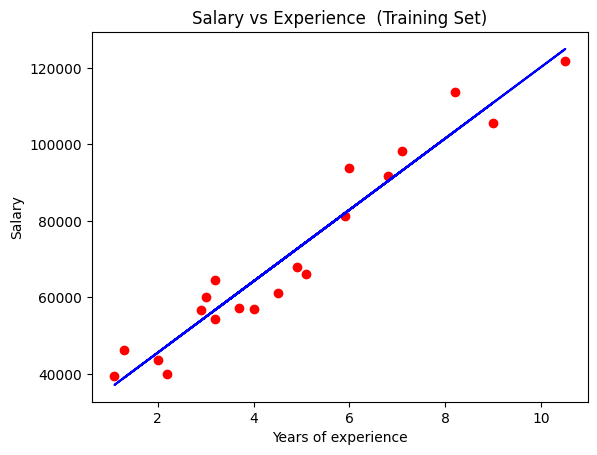

In [11]:

plt.scatter(X_Train, Y_Train, color = 'red')
plt.plot(X_Train, regressor.predict(X_Train), color = 'blue')
plt.title('Salary vs Experience  (Training Set)')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.show()

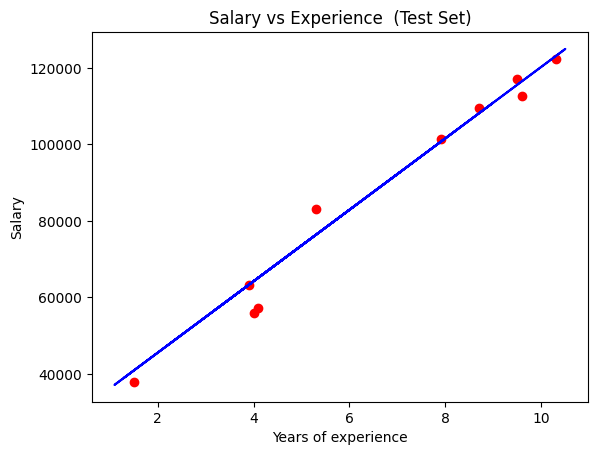

In [12]:


plt.scatter(X_Test, Y_Test, color = 'red')
plt.plot(X_Train, regressor.predict(X_Train), color = 'blue')
plt.title('Salary vs Experience  (Test Set)')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.show()

Test sum of squared residuals: 210260373.29511297


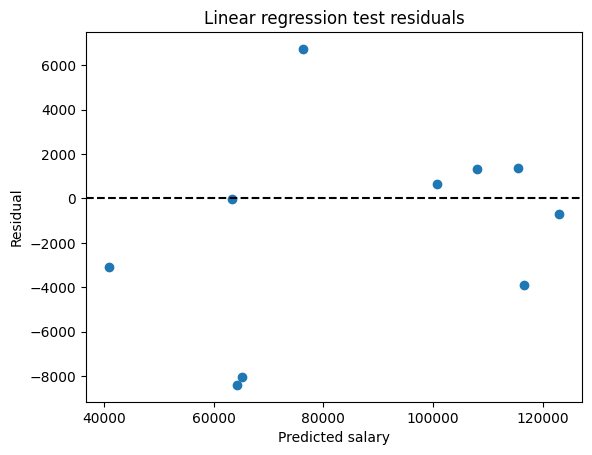

In [13]:
residuals=Y_Test-Y_Pred
print('Test sum of squared residuals:',np.sum(residuals**2))
plt.figure();plt.scatter(Y_Pred,residuals);plt.axhline(0,color='black',linestyle='--');plt.xlabel('Predicted salary');plt.ylabel('Residual');plt.title('Linear regression test residuals');plt.show()